In [ ]:
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
import numpy as np
import os

def cut_fits_pair(sci_fits_path, weight_fits_path, rows, cols, output_dir='tiles', output_prefix='tile'):
   
    os.makedirs(output_dir, exist_ok=True)

    # Load science and weight data
    with fits.open(sci_fits_path) as hdul_sci:
        data_sci = hdul_sci[0].data
        header_sci = hdul_sci[0].header
        wcs_sci = WCS(header_sci)

    with fits.open(weight_fits_path) as hdul_wt:
        data_wt = hdul_wt[0].data

    assert data_sci.shape == data_wt.shape, "Science and weight FITS must have the same shape"

    ny, nx = data_sci.shape
    tile_height = ny // rows
    tile_width = nx // cols

    tile_count = 0
    for i in range(rows):
        for j in range(cols):
            y0 = i * tile_height
            x0 = j * tile_width
            y1 = (i + 1) * tile_height if i < rows - 1 else ny
            x1 = (j + 1) * tile_width if j < cols - 1 else nx

            cutout_center = ((y0 + y1) // 2, (x0 + x1) // 2)
            cutout_size = (y1 - y0, x1 - x0)

            cutout_sci = Cutout2D(data_sci, position=cutout_center, size=cutout_size, wcs=wcs_sci, mode='partial')
            cutout_wt = Cutout2D(data_wt, position=cutout_center, size=cutout_size, wcs=wcs_sci, mode='partial', fill_value=0)

            # Create header with updated WCS
            sci_header = cutout_sci.wcs.to_header()

            # Save science tile
            fits.PrimaryHDU(data=cutout_sci.data, header=sci_header)\
                .writeto(os.path.join(output_dir, f"{output_prefix}_SCI_{i}_{j}.fits"), overwrite=True)

            # Save weight tile
            fits.PrimaryHDU(data=cutout_wt.data, header=sci_header)\
                .writeto(os.path.join(output_dir, f"{output_prefix}_WT_{i}_{j}.fits"), overwrite=True)

            print(f"Saved tile ({i},{j})")
            tile_count += 1

    print(f"Total tiles saved per type: {tile_count}")

if __name__ == "__main__":
    input_sci = "/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/mosaic_i_cut.fits"
    input_wt  = "/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/weight_mosaic_itrim_mask.fits"
    output_dir = os.path.dirname(input_sci)

    cut_fits_pair(input_sci, input_wt, rows=3, cols=3, output_dir=output_dir, output_prefix='mosaic_i_tile')


Saved tile (0,0)
Saved tile (0,1)
Saved tile (0,2)
Saved tile (1,0)
Saved tile (1,1)
Saved tile (1,2)
Saved tile (2,0)
Saved tile (2,1)
Saved tile (2,2)
Total tiles saved per type: 9


In [ ]:
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame
import os

def _get_column_names(read_line_object: List[str]) -> List[str]: 
    return [line.split()[2] for line in read_line_object if line.startswith('#')]

def _get_rows(read_line_object: List[str]) -> List[List[float]]:
    return [list(map(float, line.split())) for line in read_line_object if not line.startswith('#')]

def split_names_and_data(read_line_object: List[str]) -> Tuple[List[str], List[List[float]]]:
    return _get_column_names(read_line_object), _get_rows(read_line_object)

def read_cat(sextractor_catalog: str) -> DataFrame:
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    return pd.DataFrame(data, columns=column_names)

def cross_match(ra_new: np.ndarray, dec_new: np.ndarray, ra_catalog: np.ndarray, dec_catalog: np.ndarray):
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    sep_constraint = d2d < 1.0 * u.arcsec
    return np.where(sep_constraint)[0], idx[sep_constraint]

class CatalogMatcher:
    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str, band: str = 'i'):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path, engine='python')
        self.band = band.lower()

    def match_catalogs(self):
        ra_decam = np.array(self.sextractor_catalog['ALPHAPEAK_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTAPEAK_J2000'])
        pan = self.panstarrs_catalog
        ra_col, dec_col = f"{self.band}ra", f"{self.band}dec"
        pan = pan[(pan[ra_col] > -999) & (pan[dec_col] > -90) & (pan[dec_col] < 90)].reset_index(drop=True)
        ra_panstars, dec_panstars = np.array(pan[ra_col]), np.array(pan[dec_col])
        if len(ra_panstars) == 0 or len(dec_panstars) == 0:
            raise ValueError("Pan-STARRS catalog has no valid coordinates.")
        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)
        return self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True), pan.iloc[idx_panstars].reset_index(drop=True)

    def compute_centroid_offset(self, matched_decam: DataFrame, matched_panstars: DataFrame):
        ra_offset = (matched_decam['ALPHAPEAK_J2000'].values - matched_panstars[f'{self.band}ra'].values) * 3600.0
        dec_offset = (matched_decam['DELTAPEAK_J2000'].values - matched_panstars[f'{self.band}dec'].values) * 3600.0
        return np.median(ra_offset), np.median(dec_offset)

    def apply_offset_correction(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                                 ra_offset: float, dec_offset: float):
        matched_decam = matched_decam.copy()
        matched_panstars = matched_panstars.copy()
        matched_decam['RA_CORRECTED'] = matched_decam['ALPHAPEAK_J2000'] - (ra_offset / 3600.0)
        matched_decam['DEC_CORRECTED'] = matched_decam['DELTAPEAK_J2000'] - (dec_offset / 3600.0)
        matched_panstars['RA_CORRECTED'] = matched_panstars[f'{self.band}ra'] + (ra_offset / 3600.0)
        matched_panstars['DEC_CORRECTED'] = matched_panstars[f'{self.band}dec'] + (dec_offset / 3600.0)
        return matched_decam, matched_panstars

    def save_matches(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                     decam_out: str, pan_out: str):
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

if __name__ == '__main__':
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/Pannstar_casjobs.csv'
    OUTPUT_DIR = '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched'
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    catalog_files = [
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i0.cat',
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i1.cat',
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i2.cat',
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i10.cat',
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i11.cat',
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i12.cat',
    ]

    for cat_file in catalog_files:
        try:
            base_filename = os.path.splitext(os.path.basename(cat_file))[0]
            print(f"\nProcessing: {base_filename}")
            matcher = CatalogMatcher(cat_file, PANSTARRS_PATH, band='i')
            matched_decam, matched_panstars = matcher.match_catalogs()
            if matched_decam.empty or matched_panstars.empty:
                print(f"No matches for {base_filename}")
                continue
            ra_offset, dec_offset = matcher.compute_centroid_offset(matched_decam, matched_panstars)
            matched_decam_corr, matched_panstars_corr = matcher.apply_offset_correction(
                matched_decam, matched_panstars, ra_offset, dec_offset)
            matcher.save_matches(
                matched_decam_corr,
                matched_panstars_corr,
                os.path.join(OUTPUT_DIR, base_filename + '_decam_matched.cat'),
                os.path.join(OUTPUT_DIR, base_filename + '_panstarrs_matched.csv')
            )
        except Exception as e:
            print(f"Error processing {cat_file}: {e}")



Processing: i0
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i0_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i0_panstarrs_matched.csv

Processing: i1
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i1_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i1_panstarrs_matched.csv

Processing: i2
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i2_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i2_panstarrs_matched.csv

Processing: i10
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i10_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i10_panstarrs_matched.csv

Processing: i11
Saved matched DECam to: 

In [2]:
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame
import os

def _get_column_names(read_line_object: List[str]) -> List[str]:
    return [line.split()[2] for line in read_line_object if line.startswith('#')]

def _get_rows(read_line_object: List[str]) -> List[List[float]]:
    return [list(map(float, line.split())) for line in read_line_object if not line.startswith('#')]

def split_names_and_data(read_line_object: List[str]) -> Tuple[List[str], List[List[float]]]:
    return _get_column_names(read_line_object), _get_rows(read_line_object)

def read_cat(sextractor_catalog: str) -> DataFrame:
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    return pd.DataFrame(data, columns=column_names)

def cross_match(ra_new: np.ndarray, dec_new: np.ndarray, ra_catalog: np.ndarray, dec_catalog: np.ndarray):
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    sep_constraint = d2d < 1.0 * u.arcsec
    return np.where(sep_constraint)[0], idx[sep_constraint]

class CatalogMatcher:
    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str, band: str = 'i'):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path, engine='python')
        self.band = band.lower()

    def match_catalogs(self):
        ra_decam = np.array(self.sextractor_catalog['ALPHAPEAK_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTAPEAK_J2000'])
        pan = self.panstarrs_catalog
        ra_col, dec_col = f"{self.band}ra", f"{self.band}dec"
        pan = pan[(pan[ra_col] > -999) & (pan[dec_col] > -90) & (pan[dec_col] < 90)].reset_index(drop=True)
        ra_panstars, dec_panstars = np.array(pan[ra_col]), np.array(pan[dec_col])
        if len(ra_panstars) == 0 or len(dec_panstars) == 0:
            raise ValueError("Pan-STARRS catalog has no valid coordinates.")
        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)
        return self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True), pan.iloc[idx_panstars].reset_index(drop=True)

    def compute_centroid_offset(self, matched_decam: DataFrame, matched_panstars: DataFrame):
        ra_offset = (matched_decam['ALPHAPEAK_J2000'].values - matched_panstars[f'{self.band}ra'].values) * 3600.0
        dec_offset = (matched_decam['DELTAPEAK_J2000'].values - matched_panstars[f'{self.band}dec'].values) * 3600.0
        return np.median(ra_offset), np.median(dec_offset)

    def apply_offset_correction(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                                 ra_offset: float, dec_offset: float):
        matched_decam = matched_decam.copy()
        matched_panstars = matched_panstars.copy()
        matched_decam['RA_CORRECTED'] = matched_decam['ALPHAPEAK_J2000'] - (ra_offset / 3600.0)
        matched_decam['DEC_CORRECTED'] = matched_decam['DELTAPEAK_J2000'] - (dec_offset / 3600.0)
        matched_panstars['RA_CORRECTED'] = matched_panstars[f'{self.band}ra'] + (ra_offset / 3600.0)
        matched_panstars['DEC_CORRECTED'] = matched_panstars[f'{self.band}dec'] + (dec_offset / 3600.0)
        return matched_decam, matched_panstars

    def save_matches(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                     decam_out: str, pan_out: str):
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

if __name__ == '__main__':
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/Pannstar_casjobs.csv'
    OUTPUT_DIR = '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched'
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    catalog_files = [
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i_0_0.cat',
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i_0_1.cat',
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i_0_2.cat',
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i_1_0.cat',
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i_1_1.cat',
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i_1_2.cat',
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i_2_0.cat',
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i_2_1.cat',
        '/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/i_2_2.cat',
    ]

    for cat_file in catalog_files:
        try:
            base_filename = os.path.splitext(os.path.basename(cat_file))[0]
            print(f"\nProcessing: {base_filename}")
            matcher = CatalogMatcher(cat_file, PANSTARRS_PATH, band='i')
            matched_decam, matched_panstars = matcher.match_catalogs()
            if matched_decam.empty or matched_panstars.empty:
                print(f"No matches for {base_filename}")
                continue
            ra_offset, dec_offset = matcher.compute_centroid_offset(matched_decam, matched_panstars)
            matched_decam_corr, matched_panstars_corr = matcher.apply_offset_correction(
                matched_decam, matched_panstars, ra_offset, dec_offset)
            matcher.save_matches(
                matched_decam_corr,
                matched_panstars_corr,
                os.path.join(OUTPUT_DIR, base_filename + '_decam_matched.cat'),
                os.path.join(OUTPUT_DIR, base_filename + '_panstarrs_matched.csv')
            )
        except Exception as e:
            print(f"Error processing {cat_file}: {e}")



Processing: i_0_0
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i_0_0_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i_0_0_panstarrs_matched.csv

Processing: i_0_1
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i_0_1_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i_0_1_panstarrs_matched.csv

Processing: i_0_2
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i_0_2_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i_0_2_panstarrs_matched.csv

Processing: i_1_0
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i_1_0_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched/i_1_0_panstarrs_matched.csv

Process

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip
import os

# ---------- Read DECam Catalog ----------
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# ---------- Read Pan-STARRS Catalog ----------
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ---------- Star Selection ----------
def is_star_ps1(ps_df, band='i', threshold=0.05):
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag) < threshold

# ---------- Transform PS1 i-band to DECam System ----------
def compute_transformed_z(ps_df):
    z_ps1 = ps_df["zPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    return i_ps1 - 0.155 * (r_ps1 - i_ps1) + 0.015

# ---------- Compute Zero Point ----------
def compute_zero_point(decam_df, ps_df, tile_name):
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)

    mag_ps_transformed = compute_transformed_z(ps_df)

    bad_ps_mask = (
        (ps_df["zPSFMag"] > 100) | (ps_df["rPSFMag"] > 100) | (ps_df["iPSFMag"] > 100) |
        (ps_df["zPSFMag"] < -20) | (ps_df["rPSFMag"] < -20) | (ps_df["iPSFMag"] < -20)
    )

    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    valid &= ~bad_ps_mask

    mag_decam = mag_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]

    delta_mag = mag_ps_transformed - mag_decam

    # Existing filters
    y_valid = (delta_mag > 28) & (delta_mag < 60)
    x_valid = (mag_ps_transformed > 16) & (mag_ps_transformed < 20)

    # New filter to keep delta_mag between 30.8 and 31.1
    delta_mag_range = (delta_mag >= 30.8) & (delta_mag <= 31.1)

    combined = y_valid & x_valid & delta_mag_range

    mag_ps_transformed = mag_ps_transformed[combined]
    delta_mag = delta_mag[combined]

    clipped, _, _ = sigmaclip(delta_mag, low=3, high=3)
    clipped = clipped[~np.isnan(clipped) & ~np.isinf(clipped)]

    if len(clipped) == 0:
        print(f"{tile_name}: No data after sigma clipping.")
        return np.nan, np.nan

    zp = np.median(clipped)
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    # Plot
    plt.figure(figsize=(8, 5))
    plt.scatter(mag_ps_transformed, delta_mag, s=10, alpha=0.5, label="Stars (16 < i < 20)")
    plt.axhline(zp, color='g', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("Transformed PS1 i (star-like)")
    plt.ylabel("PS1 (transformed) - DECam MAG_AUTO")
    plt.title(f"Zero Point Calibration: {tile_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plot_path = os.path.join(matched_dir, f"{tile_name}_zeropoint_plot.png")
    plt.savefig(plot_path)
    plt.close()

    return zp, zp_err


# ---------- Main Loop ----------
matched_dir = "/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched"
tile_names = ["i0", "i1", "i2", "i10", "i11", "i12"]

for tile in tile_names:
    decam_file = os.path.join(matched_dir, f"{tile}_decam_matched.cat")
    ps_file = os.path.join(matched_dir, f"{tile}_panstarrs_matched.csv")

    if not os.path.exists(decam_file) or not os.path.exists(ps_file):
        print(f"Skipping {tile}: Missing matched files.")
        continue

    try:
        decam_df = read_decam_catalog(decam_file)
        ps_df = read_ps_catalog(ps_file)

        star_mask = is_star_ps1(ps_df, band='i', threshold=0.05)
        print(f"{tile}: Stars selected = {np.sum(star_mask)}")

        decam_df = decam_df[star_mask].reset_index(drop=True)
        ps_df = ps_df[star_mask].reset_index(drop=True)

        if len(decam_df) != len(ps_df):
            print(f"{tile}: Warning — mismatched lengths after star selection.")

        zp, zp_err = compute_zero_point(decam_df, ps_df, tile)
        if not np.isnan(zp):
            print(f"{tile}: Zero Point = {zp:.3f} ± {zp_err:.3f}")
        else:
            print(f"{tile}: Failed to compute ZP.")
    except Exception as e:
        print(f"{tile}: Error — {e}")


i0: Stars selected = 1121
i0: Zero Point = 30.939 ± 0.008
i1: Stars selected = 2051
i1: Zero Point = 30.959 ± 0.004
i2: Stars selected = 1454
i2: Zero Point = 30.956 ± 0.004
i10: Stars selected = 1255
i10: Zero Point = 30.899 ± 0.010
i11: Stars selected = 2166
i11: Zero Point = 30.914 ± 0.004
i12: Stars selected = 1509
i12: Zero Point = 30.925 ± 0.004


i_0_0: Stars selected = 591


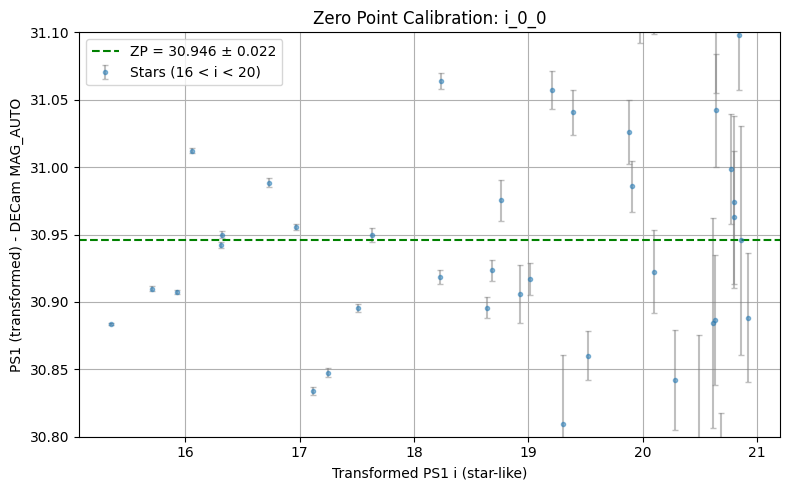

i_0_0: Zero Point = 30.946 ± 0.022
i_0_1: Stars selected = 1196


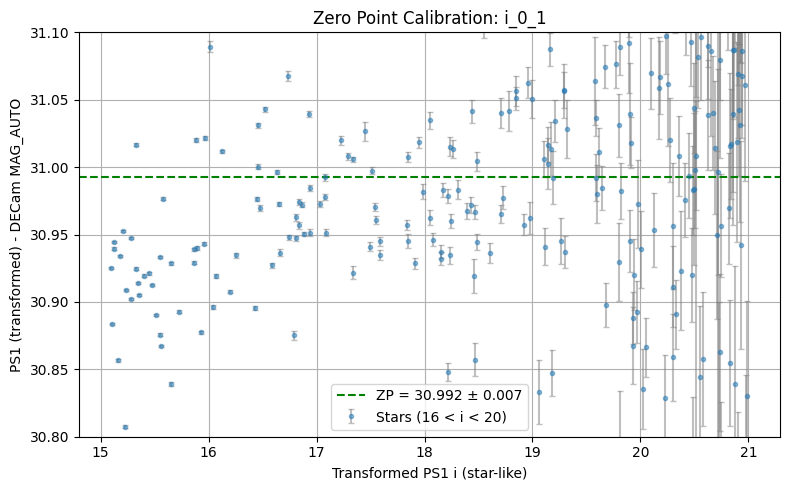

i_0_1: Zero Point = 30.992 ± 0.007
i_0_2: Stars selected = 801


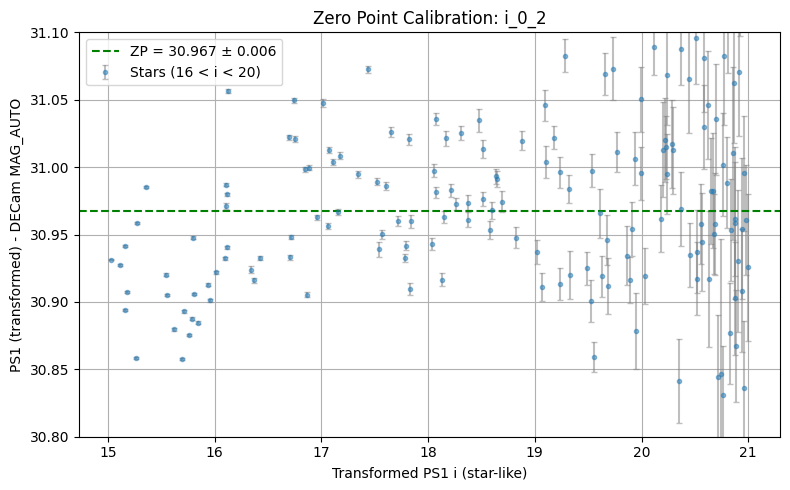

i_0_2: Zero Point = 30.967 ± 0.006
i_1_0: Stars selected = 952


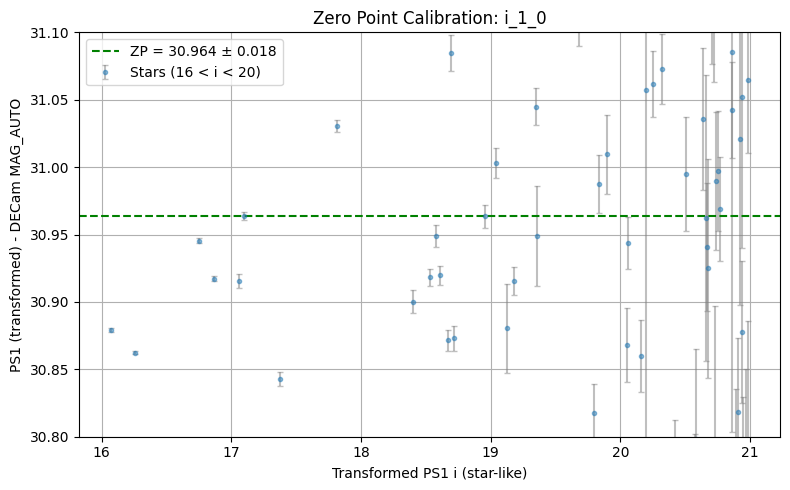

i_1_0: Zero Point = 30.964 ± 0.018
i_1_1: Stars selected = 1343


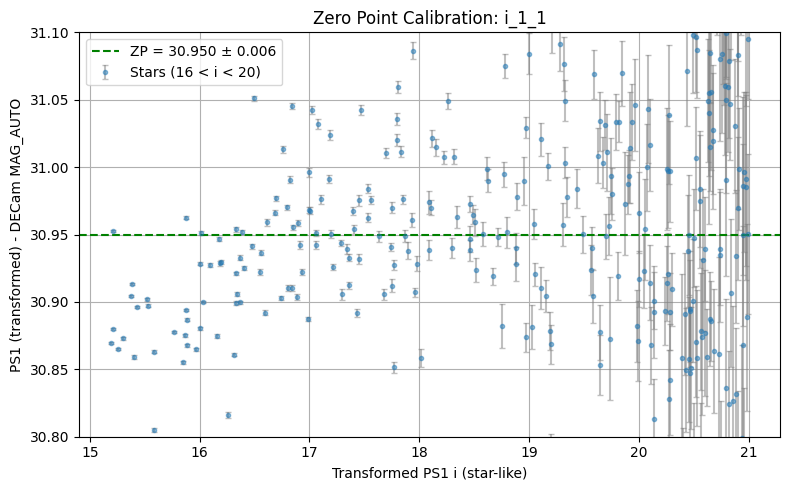

i_1_1: Zero Point = 30.950 ± 0.006
i_1_2: Stars selected = 1366


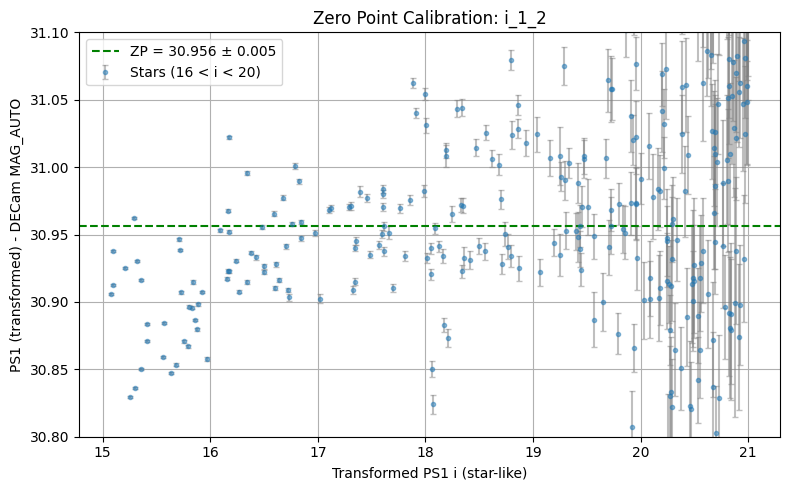

i_1_2: Zero Point = 30.956 ± 0.005
i_2_0: Stars selected = 578


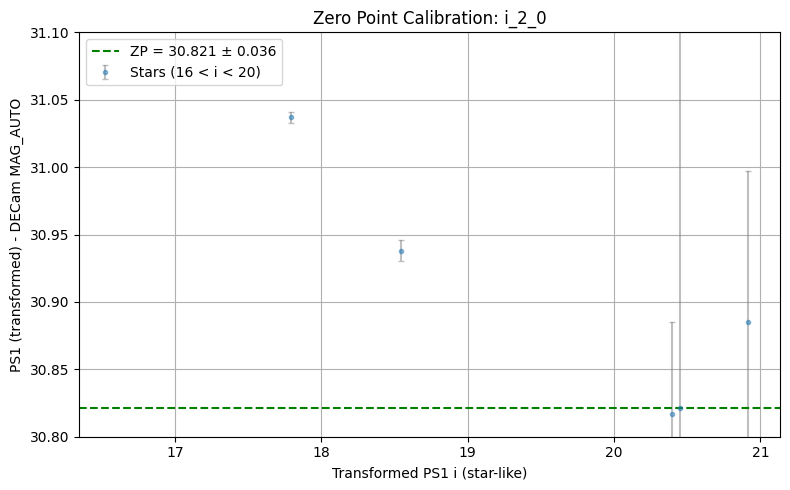

i_2_0: Zero Point = 30.821 ± 0.036
i_2_1: Stars selected = 1144


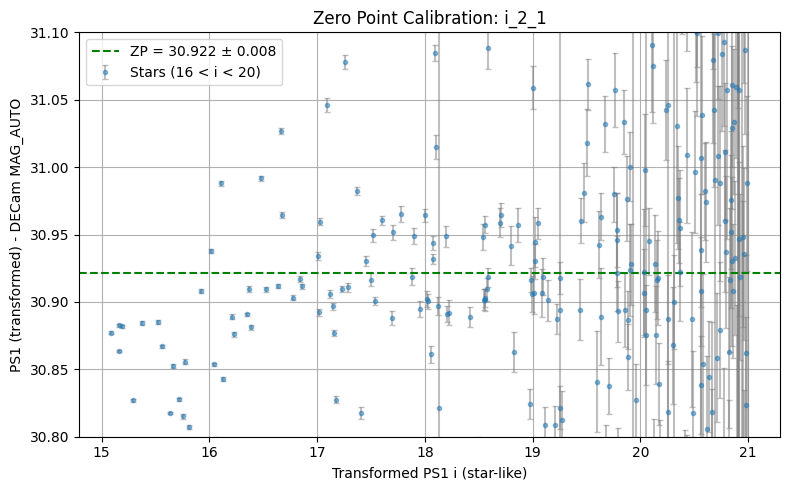

i_2_1: Zero Point = 30.922 ± 0.008
i_2_2: Stars selected = 802


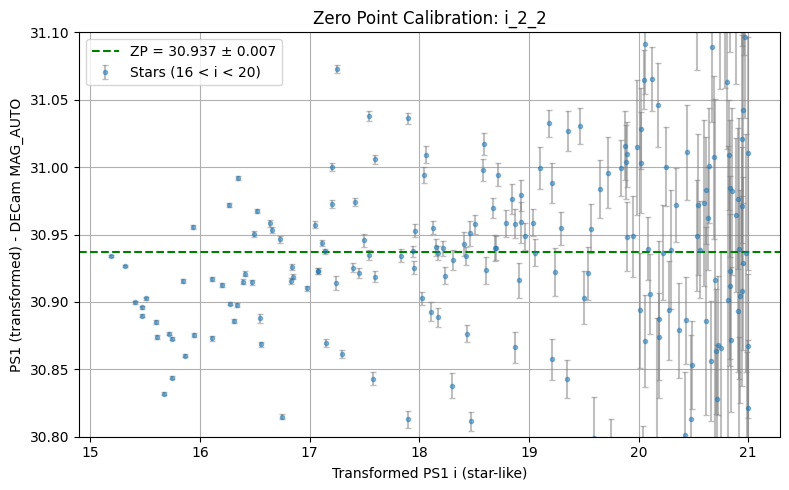

i_2_2: Zero Point = 30.937 ± 0.007


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip
import os

# ---------- Read DECam Catalog ----------
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# ---------- Read Pan-STARRS Catalog ----------
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ---------- Star Selection ----------
def is_star_ps1(ps_df, band='i', threshold=0.05):
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag) < threshold

# ---------- Transform PS1 i-band to DECam System ----------
def compute_transformed_z(ps_df):
    z_ps1 = ps_df["zPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    return i_ps1 - 0.155 * (r_ps1 - i_ps1) + 0.015

# ---------- Compute Zero Point ----------
def compute_zero_point(decam_df, ps_df, tile_name):
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)

    mag_ps_transformed = compute_transformed_z(ps_df)

    bad_ps_mask = (
        (ps_df["zPSFMag"] > 100) | (ps_df["rPSFMag"] > 100) | (ps_df["iPSFMag"] > 100) |
        (ps_df["zPSFMag"] < -20) | (ps_df["rPSFMag"] < -20) | (ps_df["iPSFMag"] < -20)
    )

    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    valid &= ~bad_ps_mask

    mag_decam = mag_decam[valid]
    magerr_decam = magerr_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]

    # Compute error in transformed PS1 magnitude
    i_err = ps_df["iPSFMagErr"][valid]
    r_err = ps_df["rPSFMagErr"][valid]
    magerr_ps_transformed = np.sqrt((1+0.155)**2 * i_err**2 + (0.155**2) * r_err**2)

    # Total error in delta_mag
    total_magerr = np.sqrt(magerr_decam**2 + magerr_ps_transformed**2)

    delta_mag = mag_ps_transformed - mag_decam

    # Apply filters
    # Apply broader filters
    y_valid = (delta_mag > 25) & (delta_mag < 60)
    x_valid = (mag_ps_transformed > 15) & (mag_ps_transformed < 21)
    delta_mag_range = (delta_mag >= 30.5) & (delta_mag <= 31.5)

    combined = y_valid & x_valid & delta_mag_range

    mag_ps_transformed = mag_ps_transformed[combined]
    delta_mag = delta_mag[combined]
    total_magerr = total_magerr[combined]

    # Sigma clipping
    clipped, _, _ = sigmaclip(delta_mag, low=3, high=3)
    clipped = clipped[~np.isnan(clipped) & ~np.isinf(clipped)]

    if len(clipped) == 0:
        print(f"{tile_name}: No data after sigma clipping.")
        return np.nan, np.nan

    zp = np.median(clipped)
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    # Plot with error bars
    plt.figure(figsize=(8, 5))
    plt.errorbar(mag_ps_transformed, delta_mag, yerr=total_magerr, fmt='o', markersize=3,
                 alpha=0.5, ecolor='gray', capsize=2, label="Stars (16 < i < 20)")
    plt.axhline(zp, color='g', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("Transformed PS1 i (star-like)")
    plt.ylabel("PS1 (transformed) - DECam MAG_AUTO")
    plt.title(f"Zero Point Calibration: {tile_name}")
    plt.ylim(30.8, 31.1)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plot_path = os.path.join(matched_dir, f"{tile_name}_zeropoint_plot.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()

    return zp, zp_err

# ---------- Main Loop ----------
matched_dir = "/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched"

# Updated tile names for your 3x3 grid
tile_names = [
    "i_0_0", "i_0_1", "i_0_2",
    "i_1_0", "i_1_1", "i_1_2",
    "i_2_0", "i_2_1", "i_2_2"
]

for tile in tile_names:
    decam_file = os.path.join(matched_dir, f"{tile}_decam_matched.cat")
    ps_file = os.path.join(matched_dir, f"{tile}_panstarrs_matched.csv")

    if not os.path.exists(decam_file) or not os.path.exists(ps_file):
        print(f"Skipping {tile}: Missing matched files.")
        continue

    try:
        decam_df = read_decam_catalog(decam_file)
        ps_df = read_ps_catalog(ps_file)

        star_mask = is_star_ps1(ps_df, band='i', threshold=0.05)
        print(f"{tile}: Stars selected = {np.sum(star_mask)}")

        decam_df = decam_df[star_mask].reset_index(drop=True)
        ps_df = ps_df[star_mask].reset_index(drop=True)

        if len(decam_df) != len(ps_df):
            print(f"{tile}: Warning — mismatched lengths after star selection.")

        zp, zp_err = compute_zero_point(decam_df, ps_df, tile)
        if not np.isnan(zp):
            print(f"{tile}: Zero Point = {zp:.3f} ± {zp_err:.3f}")
        else:
            print(f"{tile}: Failed to compute ZP.")
    except Exception as e:
        print(f"{tile}: Error — {e}")


i0: Stars selected = 1121


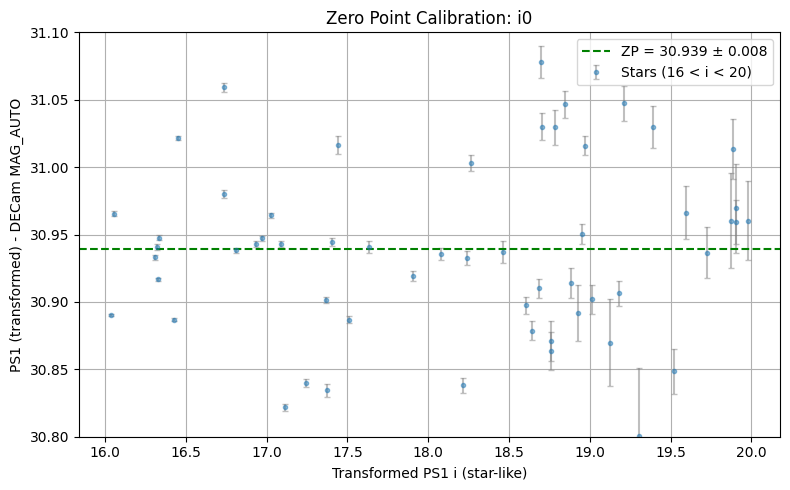

i0: Zero Point = 30.939 ± 0.008
i1: Stars selected = 2051


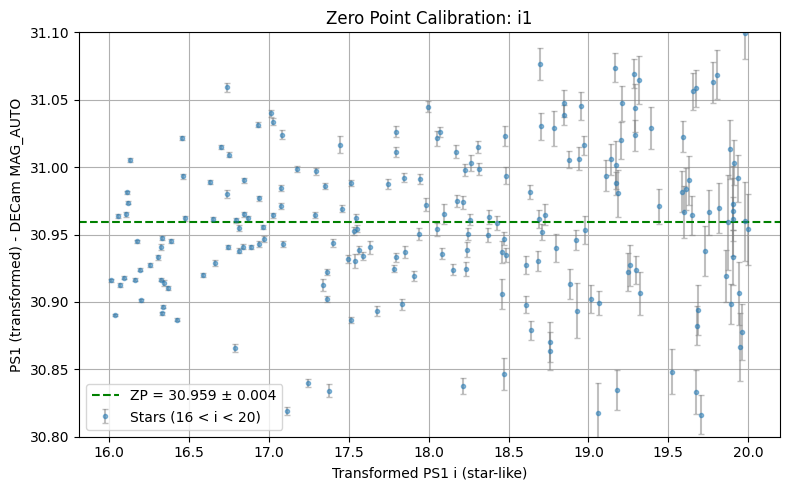

i1: Zero Point = 30.959 ± 0.004
i2: Stars selected = 1454


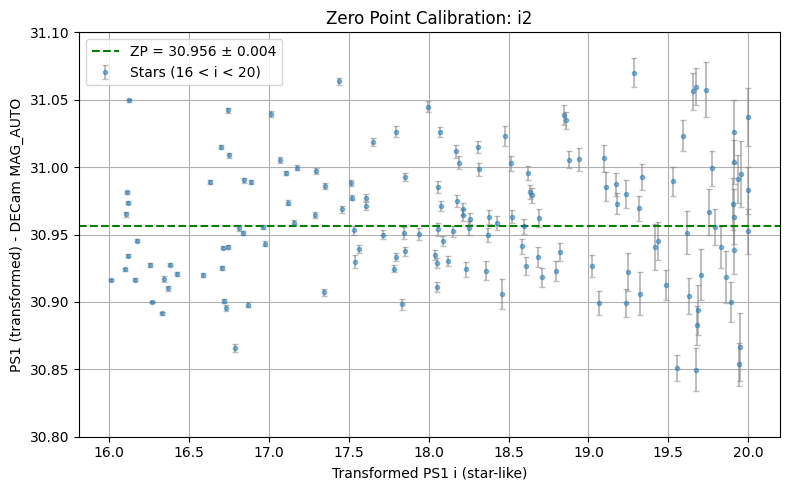

i2: Zero Point = 30.956 ± 0.004
i10: Stars selected = 1255


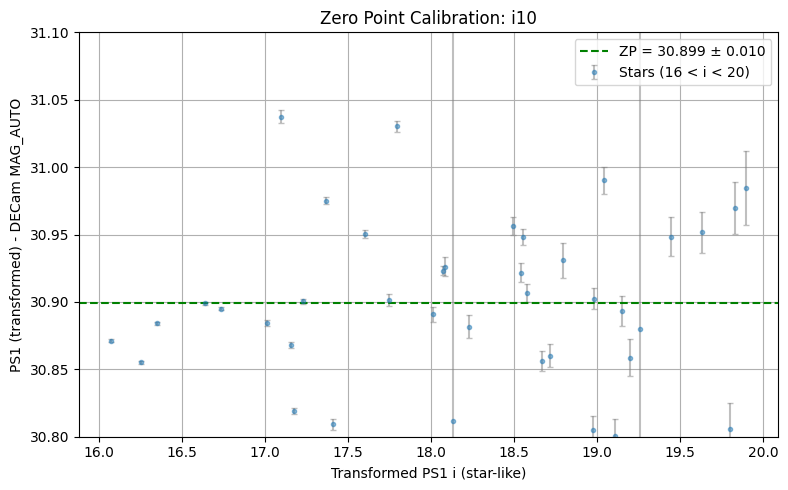

i10: Zero Point = 30.899 ± 0.010
i11: Stars selected = 2166


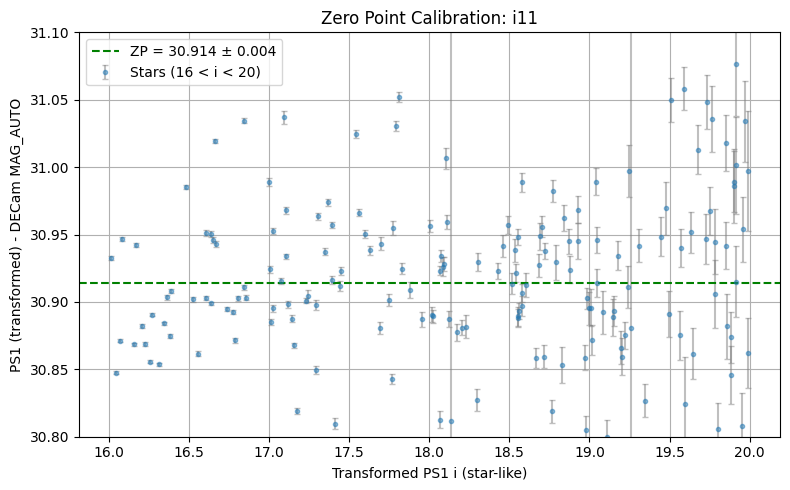

i11: Zero Point = 30.914 ± 0.004
i12: Stars selected = 1509


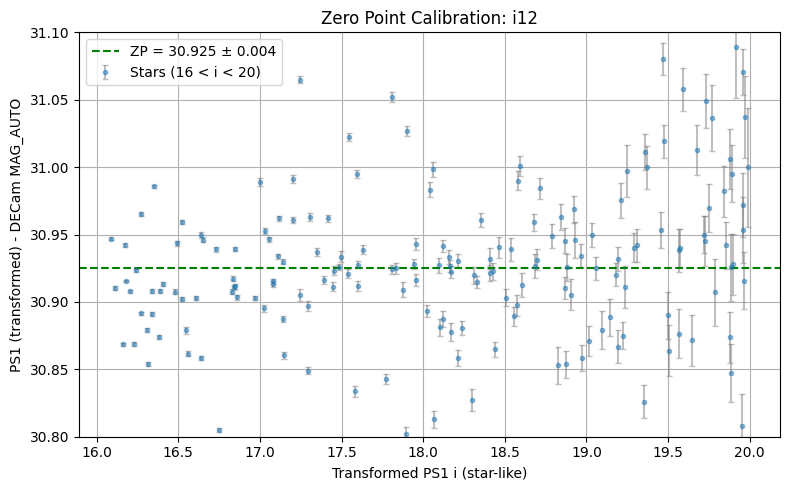

i12: Zero Point = 30.925 ± 0.004


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip
import os

# ---------- Read DECam Catalog ----------
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# ---------- Read Pan-STARRS Catalog ----------
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ---------- Star Selection ----------
def is_star_ps1(ps_df, band='i', threshold=0.05):
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag) < threshold

# ---------- Transform PS1 i-band to DECam System ----------
def compute_transformed_z(ps_df):
    z_ps1 = ps_df["zPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    return i_ps1 - 0.155 * (r_ps1 - i_ps1) + 0.015

# ---------- Compute Zero Point ----------
def compute_zero_point(decam_df, ps_df, tile_name):
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)

    mag_ps_transformed = compute_transformed_z(ps_df)

    bad_ps_mask = (
        (ps_df["zPSFMag"] > 100) | (ps_df["rPSFMag"] > 100) | (ps_df["iPSFMag"] > 100) |
        (ps_df["zPSFMag"] < -20) | (ps_df["rPSFMag"] < -20) | (ps_df["iPSFMag"] < -20)
    )

    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    valid &= ~bad_ps_mask

    mag_decam = mag_decam[valid]
    magerr_decam = magerr_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]

    # Compute error in transformed PS1 magnitude
    i_err = ps_df["iPSFMagErr"][valid]
    r_err = ps_df["rPSFMagErr"][valid]
    magerr_ps_transformed = np.sqrt(i_err**2 + (0.155**2) * (r_err**2 + i_err**2))

    # Total error in delta_mag
    total_magerr = np.sqrt(magerr_decam**2 + magerr_ps_transformed**2)

    delta_mag = mag_ps_transformed - mag_decam

    # Apply filters
    y_valid = (delta_mag > 28) & (delta_mag < 60)
    x_valid = (mag_ps_transformed > 16) & (mag_ps_transformed < 20)
    delta_mag_range = (delta_mag >= 30.8) & (delta_mag <= 31.1)

    combined = y_valid & x_valid & delta_mag_range

    mag_ps_transformed = mag_ps_transformed[combined]
    delta_mag = delta_mag[combined]
    total_magerr = total_magerr[combined]

    # Sigma clipping
    clipped, _, _ = sigmaclip(delta_mag, low=3, high=3)
    clipped = clipped[~np.isnan(clipped) & ~np.isinf(clipped)]

    if len(clipped) == 0:
        print(f"{tile_name}: No data after sigma clipping.")
        return np.nan, np.nan

    zp = np.median(clipped)
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    # Plot with error bars
    plt.figure(figsize=(8, 5))
    plt.errorbar(mag_ps_transformed, delta_mag, yerr=total_magerr, fmt='o', markersize=3,
                 alpha=0.5, ecolor='gray', capsize=2, label="Stars (16 < i < 20)")
    plt.axhline(zp, color='g', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("Transformed PS1 i (star-like)")
    plt.ylabel("PS1 (transformed) - DECam MAG_AUTO")
    plt.title(f"Zero Point Calibration: {tile_name}")
    plt.ylim(30.8, 31.1)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plot_path = os.path.join(matched_dir, f"{tile_name}_zeropoint_plot.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()

    return zp, zp_err

# ---------- Main Loop ----------
matched_dir = "/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched"
tile_names = ["i0", "i1", "i2", "i10", "i11", "i12"]

for tile in tile_names:
    decam_file = os.path.join(matched_dir, f"{tile}_decam_matched.cat")
    ps_file = os.path.join(matched_dir, f"{tile}_panstarrs_matched.csv")

    if not os.path.exists(decam_file) or not os.path.exists(ps_file):
        print(f"Skipping {tile}: Missing matched files.")
        continue

    try:
        decam_df = read_decam_catalog(decam_file)
        ps_df = read_ps_catalog(ps_file)

        star_mask = is_star_ps1(ps_df, band='i', threshold=0.05)
        print(f"{tile}: Stars selected = {np.sum(star_mask)}")

        decam_df = decam_df[star_mask].reset_index(drop=True)
        ps_df = ps_df[star_mask].reset_index(drop=True)

        if len(decam_df) != len(ps_df):
            print(f"{tile}: Warning — mismatched lengths after star selection.")

        zp, zp_err = compute_zero_point(decam_df, ps_df, tile)
        if not np.isnan(zp):
            print(f"{tile}: Zero Point = {zp:.3f} ± {zp_err:.3f}")
        else:
            print(f"{tile}: Failed to compute ZP.")
    except Exception as e:
        print(f"{tile}: Error — {e}")


i0: Stars selected = 1121


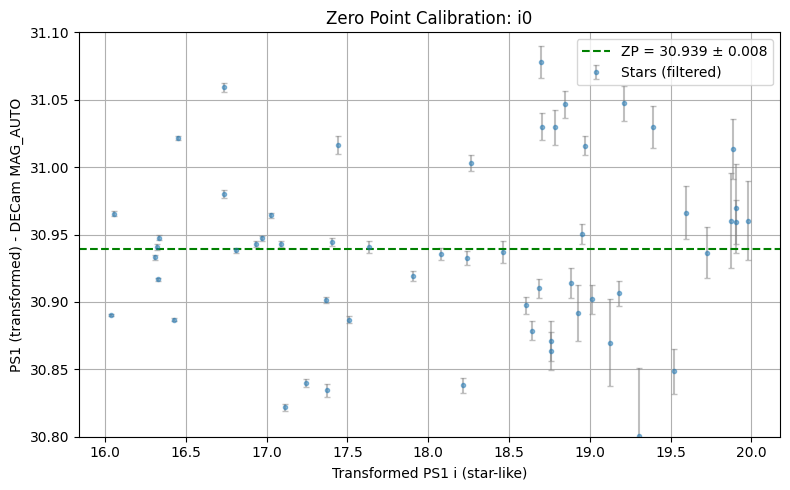

i0: Zero Point = 30.939 ± 0.008
i1: Stars selected = 2051


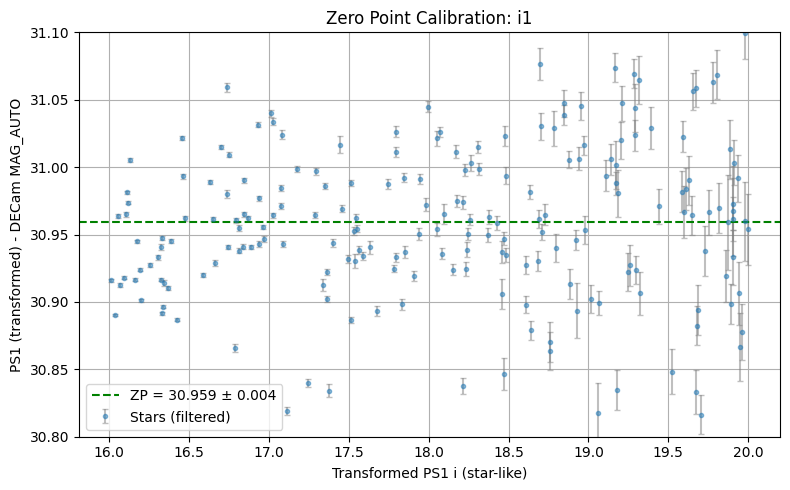

i1: Zero Point = 30.959 ± 0.004
i2: Stars selected = 1454


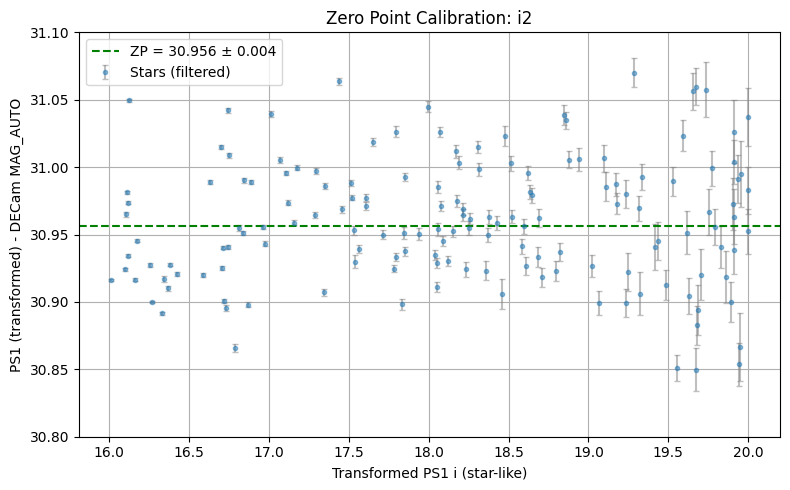

i2: Zero Point = 30.956 ± 0.004
i10: Stars selected = 1255


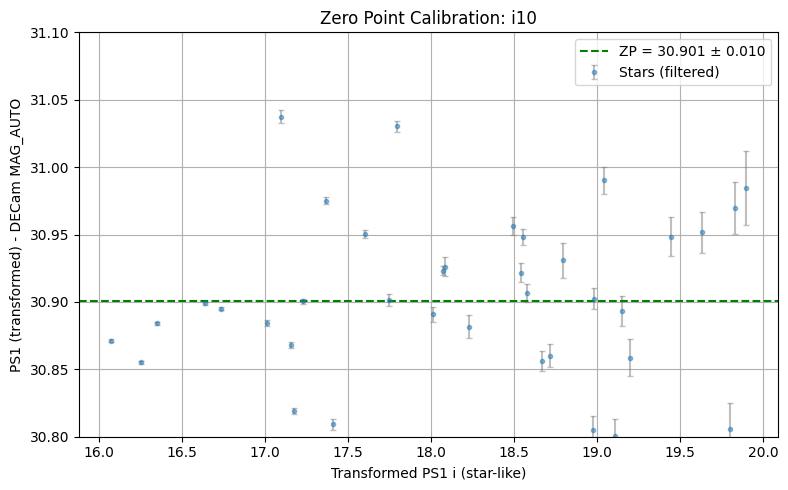

i10: Zero Point = 30.901 ± 0.010
i11: Stars selected = 2166


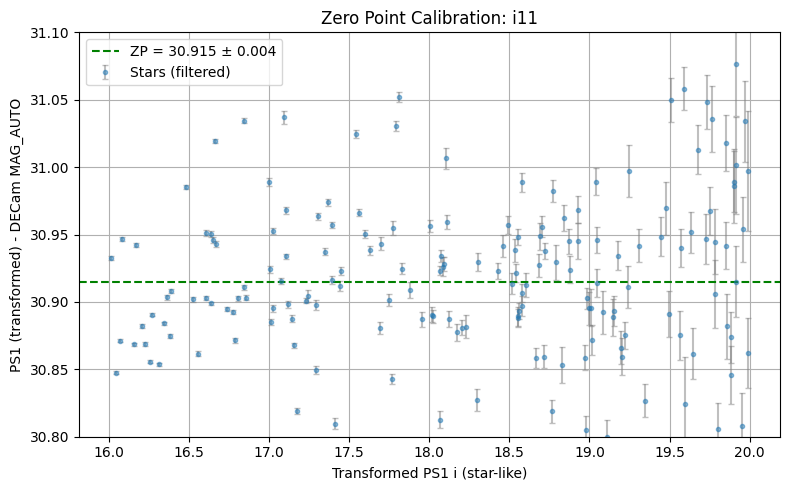

i11: Zero Point = 30.915 ± 0.004
i12: Stars selected = 1509


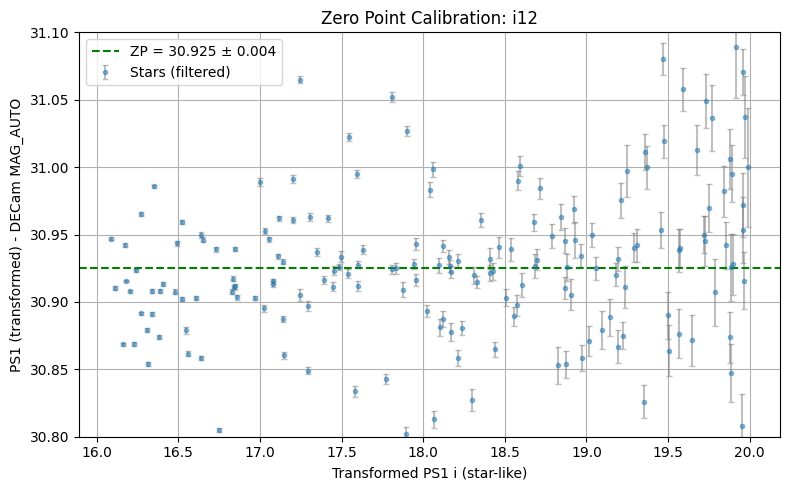

i12: Zero Point = 30.925 ± 0.004


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip
import os

# ---------- Read DECam Catalog ----------
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# ---------- Read Pan-STARRS Catalog ----------
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ---------- Star Selection ----------
def is_star_ps1(ps_df, band='i', threshold=0.05):
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag) < threshold

# ---------- Transform PS1 i-band to DECam System ----------
def compute_transformed_z(ps_df):
    z_ps1 = ps_df["zPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    return i_ps1 - 0.155 * (r_ps1 - i_ps1) + 0.015

# ---------- Compute Zero Point ----------
def compute_zero_point(decam_df, ps_df, tile_name):
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)

    mag_ps_transformed = compute_transformed_z(ps_df)

    bad_ps_mask = (
        (ps_df["zPSFMag"] > 100) | (ps_df["rPSFMag"] > 100) | (ps_df["iPSFMag"] > 100) |
        (ps_df["zPSFMag"] < -20) | (ps_df["rPSFMag"] < -20) | (ps_df["iPSFMag"] < -20)
    )

    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    valid &= ~bad_ps_mask

    mag_decam = mag_decam[valid]
    magerr_decam = magerr_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]

    i_err = ps_df["iPSFMagErr"][valid]
    r_err = ps_df["rPSFMagErr"][valid]
    magerr_ps_transformed = np.sqrt(i_err**2 + (0.155**2) * (r_err**2 + i_err**2))
    total_magerr = np.sqrt(magerr_decam**2 + magerr_ps_transformed**2)
    delta_mag = mag_ps_transformed - mag_decam

    # Apply filters
    y_valid = (delta_mag > 28) & (delta_mag < 60)
    x_valid = (mag_ps_transformed > 16) & (mag_ps_transformed < 20)
    delta_mag_range = (delta_mag >= 30.8) & (delta_mag <= 31.1)
    combined = y_valid & x_valid & delta_mag_range

    mag_ps_transformed = mag_ps_transformed[combined]
    delta_mag = delta_mag[combined]
    total_magerr = total_magerr[combined]

    # --- NEW: Remove large error bars ---
    max_total_error = 0.5  # can adjust (e.g., 0.15 or 0.1)
    error_mask = total_magerr < max_total_error
    mag_ps_transformed = mag_ps_transformed[error_mask]
    delta_mag = delta_mag[error_mask]
    total_magerr = total_magerr[error_mask]

    # Sigma clipping
    clipped, _, _ = sigmaclip(delta_mag, low=3, high=3)
    clipped = clipped[~np.isnan(clipped) & ~np.isinf(clipped)]

    if len(clipped) == 0:
        print(f"{tile_name}: No data after sigma clipping.")
        return np.nan, np.nan

    zp = np.median(clipped)
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    # Plot
    plt.figure(figsize=(8, 5))
    plt.errorbar(mag_ps_transformed, delta_mag, yerr=total_magerr, fmt='o', markersize=3,
                 alpha=0.5, ecolor='gray', capsize=2, label="Stars (filtered)")
    plt.axhline(zp, color='g', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("Transformed PS1 i (star-like)")
    plt.ylabel("PS1 (transformed) - DECam MAG_AUTO")
    plt.title(f"Zero Point Calibration: {tile_name}")
    plt.ylim(30.8, 31.1)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plot_path = os.path.join(matched_dir, f"{tile_name}_zeropoint_plot.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()

    return zp, zp_err


# ---------- Main Loop ----------
matched_dir = "/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched"
tile_names = ["i0", "i1", "i2", "i10", "i11", "i12"]

for tile in tile_names:
    decam_file = os.path.join(matched_dir, f"{tile}_decam_matched.cat")
    ps_file = os.path.join(matched_dir, f"{tile}_panstarrs_matched.csv")

    if not os.path.exists(decam_file) or not os.path.exists(ps_file):
        print(f"Skipping {tile}: Missing matched files.")
        continue

    try:
        decam_df = read_decam_catalog(decam_file)
        ps_df = read_ps_catalog(ps_file)

        star_mask = is_star_ps1(ps_df, band='i', threshold=0.05)
        print(f"{tile}: Stars selected = {np.sum(star_mask)}")

        decam_df = decam_df[star_mask].reset_index(drop=True)
        ps_df = ps_df[star_mask].reset_index(drop=True)

        if len(decam_df) != len(ps_df):
            print(f"{tile}: Warning — mismatched lengths after star selection.")

        zp, zp_err = compute_zero_point(decam_df, ps_df, tile)
        if not np.isnan(zp):
            print(f"{tile}: Zero Point = {zp:.3f} ± {zp_err:.3f}")
        else:
            print(f"{tile}: Failed to compute ZP.")
    except Exception as e:
        print(f"{tile}: Error — {e}")


i0: Stars selected = 1121
i0: Used 58 stars after clipping, std = 0.0726, err = 0.0095


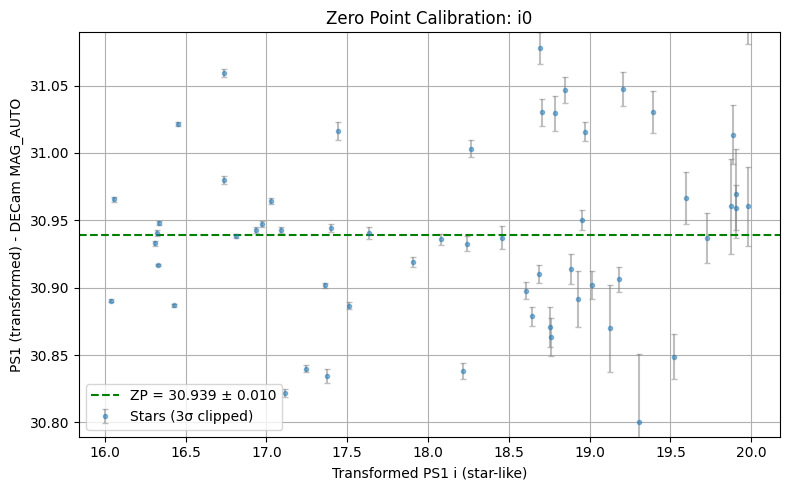

i0: Zero Point = 30.939 ± 0.010
i1: Stars selected = 2051
i1: Used 209 stars after clipping, std = 0.0679, err = 0.0047


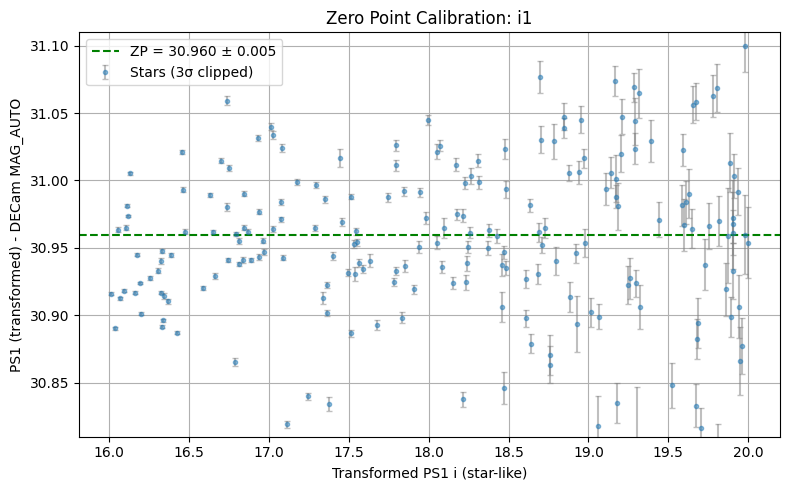

i1: Zero Point = 30.960 ± 0.005
i2: Stars selected = 1454
i2: Used 158 stars after clipping, std = 0.0570, err = 0.0045


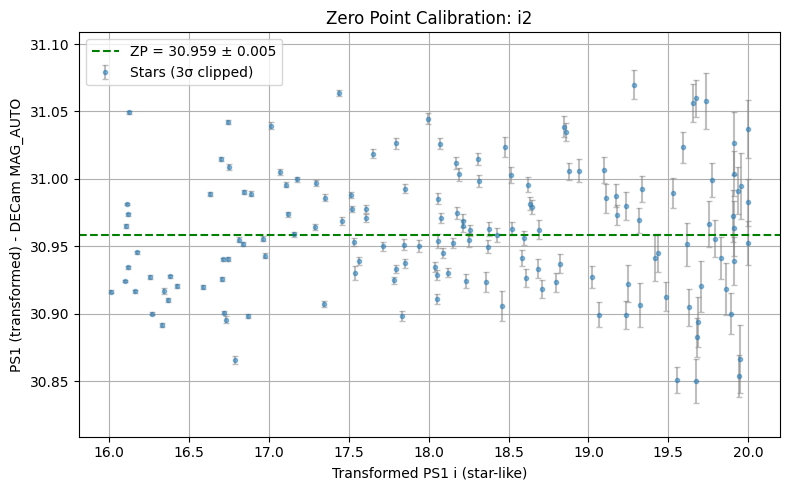

i2: Zero Point = 30.959 ± 0.005
i10: Stars selected = 1255
i10: Used 47 stars after clipping, std = 0.0887, err = 0.0129


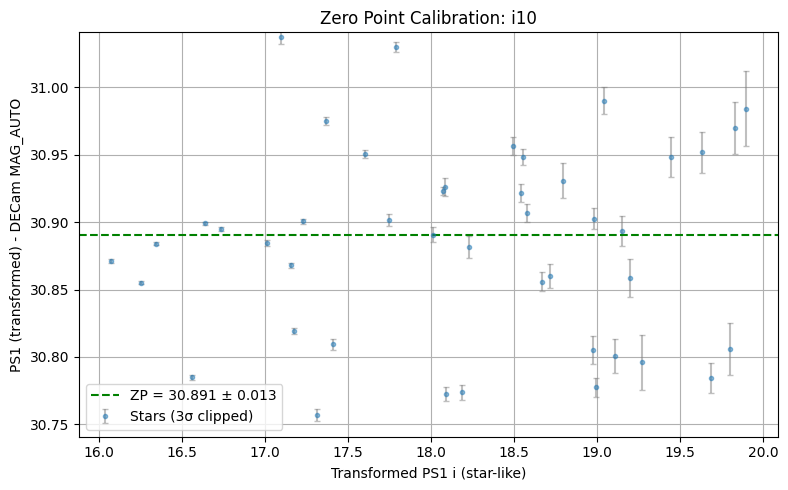

i10: Zero Point = 30.891 ± 0.013
i11: Stars selected = 2166
i11: Used 203 stars after clipping, std = 0.0876, err = 0.0061


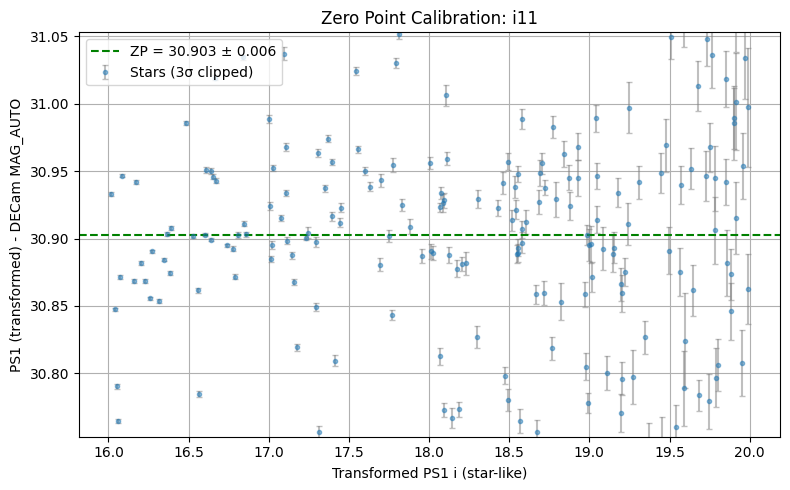

i11: Zero Point = 30.903 ± 0.006
i12: Stars selected = 1509
i12: Used 202 stars after clipping, std = 0.0878, err = 0.0062


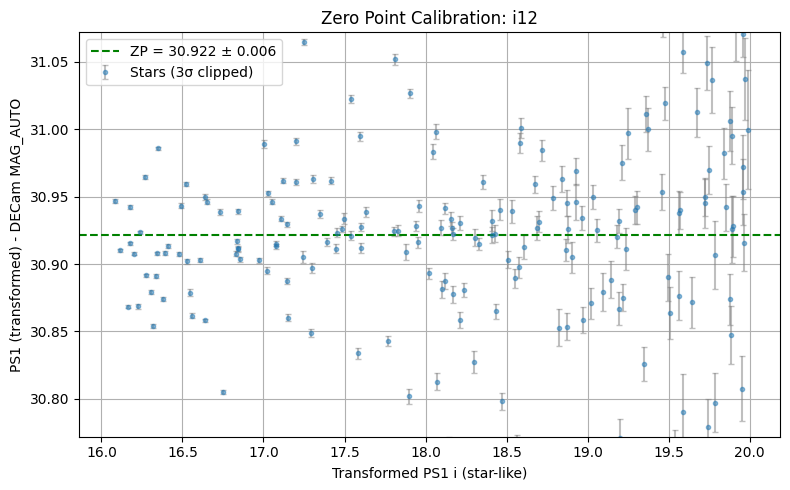

i12: Zero Point = 30.922 ± 0.006


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip
import os

# ---------- Read DECam Catalog ----------
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# ---------- Read Pan-STARRS Catalog ----------
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ---------- Star Selection ----------
def is_star_ps1(ps_df, band='i', threshold=0.05):
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag) < threshold

# ---------- Transform PS1 i-band to DECam System ----------
def compute_transformed_z(ps_df):
    z_ps1 = ps_df["zPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    return i_ps1 - 0.155 * (r_ps1 - i_ps1) + 0.015

# ---------- Compute Zero Point ----------
def compute_zero_point(decam_df, ps_df, tile_name):
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)
    mag_ps_transformed = compute_transformed_z(ps_df)

    # Remove bad photometry
    bad_ps_mask = (
        (ps_df["zPSFMag"] > 100) | (ps_df["rPSFMag"] > 100) | (ps_df["iPSFMag"] > 100) |
        (ps_df["zPSFMag"] < -20) | (ps_df["rPSFMag"] < -20) | (ps_df["iPSFMag"] < -20)
    )

    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    valid &= ~bad_ps_mask

    mag_decam = mag_decam[valid]
    magerr_decam = magerr_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]

    i_err = ps_df["iPSFMagErr"][valid]
    r_err = ps_df["rPSFMagErr"][valid]
    magerr_ps_transformed = np.sqrt(i_err**2 + (0.155**2) * (r_err**2 + i_err**2))
    total_magerr = np.sqrt(magerr_decam**2 + magerr_ps_transformed**2)
    delta_mag = mag_ps_transformed - mag_decam

    # Basic filters
    y_valid = (delta_mag > 28) & (delta_mag < 60)
    x_valid = (mag_ps_transformed > 16) & (mag_ps_transformed < 20)
    error_mask = total_magerr < 0.15  # adjust as needed
    combined = y_valid & x_valid & error_mask

    mag_ps_transformed = mag_ps_transformed[combined]
    delta_mag = delta_mag[combined]
    total_magerr = total_magerr[combined]

    # Sigma clipping using mask
    if len(delta_mag) == 0:
        print(f"{tile_name}: No data after initial filtering.")
        return np.nan, np.nan

    clipped_mask = (delta_mag > np.mean(delta_mag) - 3*np.std(delta_mag)) & \
                   (delta_mag < np.mean(delta_mag) + 3*np.std(delta_mag))

    delta_mag_clipped = delta_mag[clipped_mask]
    mag_ps_transformed_clipped = mag_ps_transformed[clipped_mask]
    total_magerr_clipped = total_magerr[clipped_mask]

    if len(delta_mag_clipped) == 0:
        print(f"{tile_name}: No data after sigma clipping.")
        return np.nan, np.nan

    # Zero point and error
    zp = np.median(delta_mag_clipped)
    zp_std = np.std(delta_mag_clipped)
    zp_err = zp_std / np.sqrt(len(delta_mag_clipped))

    print(f"{tile_name}: Used {len(delta_mag_clipped)} stars after clipping, std = {zp_std:.4f}, err = {zp_err:.4f}")

    # Plot
    plt.figure(figsize=(8, 5))
    plt.errorbar(mag_ps_transformed_clipped, delta_mag_clipped, yerr=total_magerr_clipped, fmt='o', markersize=3,
                 alpha=0.5, ecolor='gray', capsize=2, label="Stars (3σ clipped)")
    plt.axhline(zp, color='g', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("Transformed PS1 i (star-like)")
    plt.ylabel("PS1 (transformed) - DECam MAG_AUTO")
    plt.title(f"Zero Point Calibration: {tile_name}")
    plt.ylim(zp - 0.15, zp + 0.15)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plot_path = os.path.join(matched_dir, f"{tile_name}_zeropoint_plot.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()

    return zp, zp_err


# ---------- Main Loop ----------
matched_dir = "/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched"
tile_names = ["i0", "i1", "i2", "i10", "i11", "i12"]

for tile in tile_names:
    decam_file = os.path.join(matched_dir, f"{tile}_decam_matched.cat")
    ps_file = os.path.join(matched_dir, f"{tile}_panstarrs_matched.csv")

    if not os.path.exists(decam_file) or not os.path.exists(ps_file):
        print(f"Skipping {tile}: Missing matched files.")
        continue

    try:
        decam_df = read_decam_catalog(decam_file)
        ps_df = read_ps_catalog(ps_file)

        star_mask = is_star_ps1(ps_df, band='i', threshold=0.05)
        print(f"{tile}: Stars selected = {np.sum(star_mask)}")

        decam_df = decam_df[star_mask].reset_index(drop=True)
        ps_df = ps_df[star_mask].reset_index(drop=True)

        if len(decam_df) != len(ps_df):
            print(f"{tile}: Warning — mismatched lengths after star selection.")

        zp, zp_err = compute_zero_point(decam_df, ps_df, tile)
        if not np.isnan(zp):
            print(f"{tile}: Zero Point = {zp:.3f} ± {zp_err:.3f}")
        else:
            print(f"{tile}: Failed to compute ZP.")
    except Exception as e:
        print(f"{tile}: Error — {e}")


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip
import os

# ---------- Read DECam Catalog ----------
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# ---------- Read Pan-STARRS Catalog ----------
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# ---------- Star Selection ----------
def is_star_ps1(ps_df, band='i', threshold=0.05):
    psf_col = f"{band}PSFMag"
    kron_col = f"{band}KronMag"
    delta_mag = ps_df[psf_col] - ps_df[kron_col]
    return np.abs(delta_mag) < threshold

# ---------- Transform PS1 i-band to DECam System ----------
def compute_transformed_z(ps_df):
    z_ps1 = ps_df["zPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    return i_ps1 - 0.155 * (r_ps1 - i_ps1) + 0.015

# ---------- Compute Zero Point ----------
def compute_zero_point(decam_df, ps_df, tile_name):
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)

    mag_ps_transformed = compute_transformed_z(ps_df)

    bad_ps_mask = (
        (ps_df["zPSFMag"] > 100) | (ps_df["rPSFMag"] > 100) | (ps_df["iPSFMag"] > 100) |
        (ps_df["zPSFMag"] < -20) | (ps_df["rPSFMag"] < -20) | (ps_df["iPSFMag"] < -20)
    )

    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    valid &= ~bad_ps_mask

    mag_decam = mag_decam[valid]
    magerr_decam = magerr_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]

    i_err = ps_df["iPSFMagErr"][valid]
    r_err = ps_df["rPSFMagErr"][valid]
    magerr_ps_transformed = np.sqrt(i_err**2 + (0.155**2) * (r_err**2 + i_err**2))
    total_magerr = np.sqrt(magerr_decam**2 + magerr_ps_transformed**2)
    delta_mag = mag_ps_transformed - mag_decam

    # Apply filters
    y_valid = (delta_mag > 28) & (delta_mag < 60)
    x_valid = (mag_ps_transformed > 16) & (mag_ps_transformed < 20)
    delta_mag_range = (delta_mag >= 30.8) & (delta_mag <= 31.1)
    combined = y_valid & x_valid & delta_mag_range

    mag_ps_transformed = mag_ps_transformed[combined]
    delta_mag = delta_mag[combined]
    total_magerr = total_magerr[combined]

    # --- NEW: Remove large error bars ---
    max_total_error = 0.5
    error_mask = total_magerr < max_total_error
    mag_ps_transformed = mag_ps_transformed[error_mask]
    delta_mag = delta_mag[error_mask]
    total_magerr = total_magerr[error_mask]

    # Sigma clipping
    clipped, _, _ = sigmaclip(delta_mag, low=3, high=3)
    clipped = clipped[~np.isnan(clipped) & ~np.isinf(clipped)]

    if len(clipped) == 0:
        print(f"{tile_name}: No data after sigma clipping.")
        return np.nan, np.nan

    zp = np.median(clipped)
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    # Plot
    plt.figure(figsize=(8, 5))
    plt.errorbar(mag_ps_transformed, delta_mag, yerr=total_magerr, fmt='o', markersize=3,
                 alpha=0.5, ecolor='gray', capsize=2, label="Stars (filtered)")
    plt.axhline(zp, color='g', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("Transformed PS1 i (star-like)")
    plt.ylabel("PS1 (transformed) - DECam MAG_AUTO")
    plt.title(f"Zero Point Calibration: {tile_name}")
    plt.ylim(30.8, 31.1)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plot_path = os.path.join(matched_dir, f"{tile_name}_zeropoint_plot.png")
    plt.savefig(plot_path)
    plt.close()

    return zp, zp_err

# ---------- Main ----------
matched_dir = "/Users/aishwarya/Documents/Lyman_alpha/CAT/Mosaic_cut/matched"

tile_names = [
    "i_0_0", "i_0_1", "i_0_2",
    "i_1_0", "i_1_1", "i_1_2",
    "i_2_0", "i_2_1", "i_2_2"
]

for tile in tile_names:
    decam_file = os.path.join(matched_dir, f"{tile}_decam_matched.cat")
    ps_file = os.path.join(matched_dir, f"{tile}_panstarrs_matched.csv")

    if not os.path.exists(decam_file) or not os.path.exists(ps_file):
        print(f"Skipping {tile}: Missing matched files.")
        continue

    try:
        decam_df = read_decam_catalog(decam_file)
        ps_df = read_ps_catalog(ps_file)

        star_mask = is_star_ps1(ps_df, band='i', threshold=0.05)
        print(f"{tile}: Stars selected = {np.sum(star_mask)}")

        decam_df = decam_df[star_mask].reset_index(drop=True)
        ps_df = ps_df[star_mask].reset_index(drop=True)

        if len(decam_df) != len(ps_df):
            print(f"{tile}: Warning — mismatched lengths after star selection.")

        zp, zp_err = compute_zero_point(decam_df, ps_df, tile)
        if not np.isnan(zp):
            print(f"{tile}: Zero Point = {zp:.3f} ± {zp_err:.3f}")
        else:
            print(f"{tile}: Failed to compute ZP.")
    except Exception as e:
        print(f"{tile}: Error — {e}")


Skipping i_0_0: Missing matched files.
Skipping i_0_1: Missing matched files.
Skipping i_0_2: Missing matched files.
Skipping i_1_0: Missing matched files.
Skipping i_1_1: Missing matched files.
Skipping i_1_2: Missing matched files.
Skipping i_2_0: Missing matched files.
Skipping i_2_1: Missing matched files.
Skipping i_2_2: Missing matched files.


In [40]:
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
import numpy as np
import os

def cut_fits_pair(sci_fits_path, weight_fits_path, rows, cols, output_dir='tiles', output_prefix='tile'):
   
    os.makedirs(output_dir, exist_ok=True)

    # Load science and weight data
    with fits.open(sci_fits_path) as hdul_sci:
        data_sci = hdul_sci[0].data
        header_sci = hdul_sci[0].header
        wcs_sci = WCS(header_sci)

    with fits.open(weight_fits_path) as hdul_wt:
        data_wt = hdul_wt[0].data

    assert data_sci.shape == data_wt.shape, "Science and weight FITS must have the same shape"

    ny, nx = data_sci.shape
    tile_height = ny // rows
    tile_width = nx // cols

    tile_count = 0
    for i in range(rows):
        for j in range(cols):
            y0 = i * tile_height
            x0 = j * tile_width
            y1 = (i + 1) * tile_height if i < rows - 1 else ny
            x1 = (j + 1) * tile_width if j < cols - 1 else nx

            cutout_center = ((y0 + y1) // 2, (x0 + x1) // 2)
            cutout_size = (y1 - y0, x1 - x0)

            cutout_sci = Cutout2D(data_sci, position=cutout_center, size=cutout_size, wcs=wcs_sci, mode='partial')
            cutout_wt = Cutout2D(data_wt, position=cutout_center, size=cutout_size, wcs=wcs_sci, mode='partial', fill_value=0)

            # Create header with updated WCS
            sci_header = cutout_sci.wcs.to_header()

            # Save science tile
            fits.PrimaryHDU(data=cutout_sci.data, header=sci_header)\
                .writeto(os.path.join(output_dir, f"{output_prefix}_SCI_{i}_{j}.fits"), overwrite=True)

            # Save weight tile
            fits.PrimaryHDU(data=cutout_wt.data, header=sci_header)\
                .writeto(os.path.join(output_dir, f"{output_prefix}_WT_{i}_{j}.fits"), overwrite=True)

            print(f"Saved tile ({i},{j})")
            tile_count += 1

    print(f"Total tiles saved per type: {tile_count}")

if __name__ == "__main__":
    input_sci = "/Users/aishwarya/Documents/Lyman_alpha/N964/mosaic_N964_cut.fits"
    input_wt  = "/Users/aishwarya/Documents/Lyman_alpha/N964_WEIGHT/weight_mosaic_N964trim.fits"
    output_dir = os.path.dirname(input_sci)

    cut_fits_pair(input_sci, input_wt, rows=3, cols=3, output_dir=output_dir, output_prefix='mosaic_n964_tile')


Saved tile (0,0)
Saved tile (0,1)
Saved tile (0,2)
Saved tile (1,0)
Saved tile (1,1)
Saved tile (1,2)
Saved tile (2,0)
Saved tile (2,1)
Saved tile (2,2)
Total tiles saved per type: 9


In [45]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# -----------------------
# Constants and Parameters
# -----------------------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47       # Arcseconds
NARROW_BAND_APERTURES = 0.94    # Arcseconds
MIN_ERR = 0.01
SIGMA_CLIP = 3.0
PANSTARRS_CSV = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'

# -----------------------
# Functions
# -----------------------

def gaussian(x_array, mean, fwhm):
    sigma = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * sigma**2))

def calculate_k_constant(aperture_radius, seeing):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))[0]
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))[0]
    return infinite_integral / definite_integral

def calculate_k_constant_mag(aperture_radius, seeing):
    k = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k)

def straight_line(x, alpha, zpt):
    return alpha * x + zpt

def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        popt, _ = curve_fit(straight_line, x[mask], y[mask], sigma=yerr[mask], absolute_sigma=True)
        residuals = y - straight_line(x, *popt)
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std
    return x[mask], y[mask], yerr[mask], popt

def bottom_limit(x):
    return 1 * x + 28.8

def upper_limit(x):
    return 1 * x + 29.1

def read_sextractor_catalog(filepath):
    try:
        data = np.genfromtxt(filepath, comments='#')
        return data
    except Exception as e:
        raise RuntimeError(f"Error reading catalog {filepath}: {e}")

# -----------------------
# Load Pan-STARRS Data
# -----------------------

try:
    pan = pd.read_csv(PANSTARRS_CSV)
    z = pan['zPSFMag'].to_numpy()
    y = pan['yPSFMag'].to_numpy()
    z_err = pan['zPSFMagErr'].to_numpy()
    y_err = pan['yPSFMagErr'].to_numpy()
except Exception as e:
    raise RuntimeError(f"Failed to read Pan-STARRS CSV: {e}")

# -----------------------
# SExtractor Catalog List
# -----------------------

decam_files = [
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_0_0.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_0_1.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_0_2.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_1_0.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_1_1.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_1_2.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_2_0.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_2_1.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_2_2.cat'
]

# -----------------------
# Process Each Catalog
# -----------------------

for filepath in decam_files:
    print(f"\nProcessing: {os.path.basename(filepath)}")

    try:
        data = read_sextractor_catalog(filepath)
        if data.ndim != 2 or data.shape[1] < 6:
            raise ValueError("Invalid catalog format: expecting at least 6 columns")

        mag_auto = data[:, 4] + MAG_ZEROPOINT
        magerr_auto = data[:, 5]

        # Ensure size consistency with Pan-STARRS catalog
        n = min(len(z), len(mag_auto))
        z_cut = z[:n]
        y_cut = y[:n]
        z_err_cut = z_err[:n]
        y_err_cut = y_err[:n]
        mag_auto = mag_auto[:n]
        magerr_auto = magerr_auto[:n]

        # Filter valid entries
        valid_idx = y_cut != -999
        z_cut = z_cut[valid_idx]
        y_cut = y_cut[valid_idx]
        z_err_cut = z_err_cut[valid_idx]
        y_err_cut = y_err_cut[valid_idx]
        mag_auto = mag_auto[valid_idx]
        magerr_auto = magerr_auto[valid_idx]

        # Color indices
        delta_pan = z_cut - y_cut
        delta_decam = z_cut - mag_auto
        delta_pan_err = np.hypot(z_err_cut, y_err_cut)
        delta_decam_err = np.hypot(z_err_cut, magerr_auto)
        delta_decam_err = np.clip(delta_decam_err, MIN_ERR, None)

        # Color cuts
        cut_x = (delta_pan > -0.2) & (delta_pan < 0.6)
        cut_y = (delta_decam > 28.75) & (delta_decam < 29.752)
        valid = cut_x & cut_y

        delta_pan = delta_pan[valid]
        delta_decam = delta_decam[valid]
        delta_pan_err = delta_pan_err[valid]
        delta_decam_err = delta_decam_err[valid]

        # Outlier rejection
        valid_range = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
        delta_pan = delta_pan[valid_range]
        delta_decam = delta_decam[valid_range]
        delta_pan_err = delta_pan_err[valid_range]
        delta_decam_err = delta_decam_err[valid_range]

        # Sigma clipping and final fit
        delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, _ = sigma_clip_fit(
            delta_pan, delta_decam, delta_decam_err, sigma=SIGMA_CLIP
        )

        popt, pcov = curve_fit(
            straight_line,
            delta_pan_clipped,
            delta_decam_clipped,
            sigma=delta_decam_err_clipped,
            absolute_sigma=True
        )
        perr = np.sqrt(np.diag(pcov))

        # K-correction
        k_correction = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
        zpt_prime = popt[1] - k_correction

        print(f"Slope (alpha):         {popt[0]:.4f} ± {perr[0]:.4f}")
        print(f"Intercept (zpt):       {popt[1]:.4f} ± {perr[1]:.4f}")
        print(f"K-correction (mag):    {k_correction:.4f}")
        print(f"Corrected ZPT (zpt'):   {zpt_prime:.4f}")
        

    except Exception as e:
        print(f"Failed to process {filepath}: {e}")



Processing: n964_0_0.cat
Slope (alpha):         1.0993 ± 0.1357
Intercept (zpt):       28.8869 ± 0.0296
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.0407

Processing: n964_0_1.cat
Slope (alpha):         0.9854 ± 0.0685
Intercept (zpt):       28.9130 ± 0.0105
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.0668

Processing: n964_0_2.cat
Slope (alpha):         1.0385 ± 0.0929
Intercept (zpt):       28.9370 ± 0.0219
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.0908

Processing: n964_1_0.cat
Slope (alpha):         1.1763 ± 0.0725
Intercept (zpt):       28.9585 ± 0.0332
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.1123

Processing: n964_1_1.cat
Slope (alpha):         0.9309 ± 0.0541
Intercept (zpt):       28.9709 ± 0.0154
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.1248

Processing: n964_1_2.cat
Slope (alpha):         1.0276 ± 0.0690
Intercept (zpt):       28.9386 ± 0.0092
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   


Processing: n964_0_0.cat
Slope (alpha):         1.0993 ± 0.1357
Intercept (zpt):       28.8869 ± 0.0296
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.0407

Processing: n964_0_1.cat
Slope (alpha):         0.9854 ± 0.0685
Intercept (zpt):       28.9130 ± 0.0105
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.0668

Processing: n964_0_2.cat
Slope (alpha):         1.0385 ± 0.0929
Intercept (zpt):       28.9370 ± 0.0219
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.0908

Processing: n964_1_0.cat
Slope (alpha):         1.1763 ± 0.0725
Intercept (zpt):       28.9585 ± 0.0332
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.1123

Processing: n964_1_1.cat
Slope (alpha):         0.9309 ± 0.0541
Intercept (zpt):       28.9709 ± 0.0154
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.1248

Processing: n964_1_2.cat
Slope (alpha):         1.0276 ± 0.0690
Intercept (zpt):       28.9386 ± 0.0092
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   

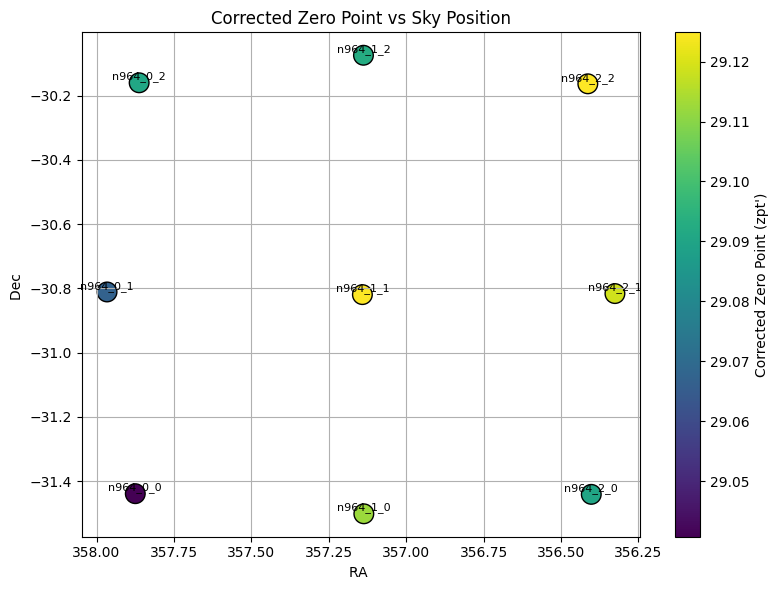

In [48]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# -----------------------
# Constants
# -----------------------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47  # arcsec
NARROW_BAND_APERTURES = 0.94  # arcsec
MIN_ERR = 0.01
SIGMA_CLIP = 3.0
PANSTARRS_CSV = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'

# -----------------------
# Functions
# -----------------------

def gaussian(x, mean, fwhm):
    sigma = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x - mean, 2.) / (2 * sigma**2))

def calculate_k_constant(aperture_radius, seeing):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))[0]
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))[0]
    return infinite_integral / definite_integral

def calculate_k_constant_mag(aperture_radius, seeing):
    k = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k)

def straight_line(x, alpha, zpt):
    return alpha * x + zpt

def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        popt, _ = curve_fit(straight_line, x[mask], y[mask], sigma=yerr[mask], absolute_sigma=True)
        residuals = y - straight_line(x, *popt)
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std
    return x[mask], y[mask], yerr[mask], popt

def bottom_limit(x):
    return 1 * x + 28.8

def upper_limit(x):
    return 1 * x + 29.1

def read_sextractor_catalog(filepath):
    try:
        data = np.genfromtxt(filepath, comments='#')
        return data
    except Exception as e:
        raise RuntimeError(f"Error reading catalog {filepath}: {e}")

# -----------------------
# Load Pan-STARRS Data
# -----------------------
pan = pd.read_csv(PANSTARRS_CSV)
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()

# -----------------------
# Catalog List
# -----------------------
decam_files = [
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_0_0.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_0_1.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_0_2.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_1_0.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_1_1.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_1_2.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_2_0.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_2_1.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_2_2.cat'
]

# -----------------------
# Process and Store Results
# -----------------------

ra_list = []
dec_list = []
zpt_corr_list = []
tile_names = []

for filepath in decam_files:
    print(f"\nProcessing: {os.path.basename(filepath)}")
    try:
        data = read_sextractor_catalog(filepath)
        if data.ndim != 2 or data.shape[1] < 10:
            raise ValueError("Invalid catalog format: expecting at least 10 columns")

        ra_center = np.mean(data[:, 8])  # ALPHAPEAK_J2000
        dec_center = np.mean(data[:, 9])  # DELTAPEAK_J2000
        mag_auto = data[:, 4] + MAG_ZEROPOINT
        magerr_auto = data[:, 5]

        # Truncate to match Pan-STARRS size
        n = min(len(z), len(mag_auto))
        z_cut = z[:n]
        y_cut = y[:n]
        z_err_cut = z_err[:n]
        y_err_cut = y_err[:n]
        mag_auto = mag_auto[:n]
        magerr_auto = magerr_auto[:n]

        valid_idx = y_cut != -999
        z_cut = z_cut[valid_idx]
        y_cut = y_cut[valid_idx]
        z_err_cut = z_err_cut[valid_idx]
        y_err_cut = y_err_cut[valid_idx]
        mag_auto = mag_auto[valid_idx]
        magerr_auto = magerr_auto[valid_idx]

        delta_pan = z_cut - y_cut
        delta_decam = z_cut - mag_auto
        delta_pan_err = np.hypot(z_err_cut, y_err_cut)
        delta_decam_err = np.hypot(z_err_cut, magerr_auto)
        delta_decam_err = np.clip(delta_decam_err, MIN_ERR, None)

        cut_x = (delta_pan > -0.2) & (delta_pan < 0.6)
        cut_y = (delta_decam > 28.75) & (delta_decam < 29.752)
        valid = cut_x & cut_y

        delta_pan = delta_pan[valid]
        delta_decam = delta_decam[valid]
        delta_pan_err = delta_pan_err[valid]
        delta_decam_err = delta_decam_err[valid]

        valid_range = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
        delta_pan = delta_pan[valid_range]
        delta_decam = delta_decam[valid_range]
        delta_pan_err = delta_pan_err[valid_range]
        delta_decam_err = delta_decam_err[valid_range]

        delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, _ = sigma_clip_fit(
            delta_pan, delta_decam, delta_decam_err, sigma=SIGMA_CLIP
        )

        popt, pcov = curve_fit(
            straight_line,
            delta_pan_clipped,
            delta_decam_clipped,
            sigma=delta_decam_err_clipped,
            absolute_sigma=True
        )
        perr = np.sqrt(np.diag(pcov))

        k_correction = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
        zpt_prime = popt[1] - k_correction

        print(f"Slope (alpha):         {popt[0]:.4f} ± {perr[0]:.4f}")
        print(f"Intercept (zpt):       {popt[1]:.4f} ± {perr[1]:.4f}")
        print(f"K-correction (mag):    {k_correction:.4f}")
        print(f"Corrected ZPT (zpt'):   {zpt_prime:.4f}")

        ra_list.append(ra_center)
        dec_list.append(dec_center)
        zpt_corr_list.append(zpt_prime)
        tile_names.append(os.path.basename(filepath).replace('.cat', ''))

    except Exception as e:
        print(f"Failed to process {filepath}: {e}")

# -----------------------
# Plot: RA vs Dec vs ZPT'
# -----------------------
plt.figure(figsize=(8, 6))
sc = plt.scatter(ra_list, dec_list, c=zpt_corr_list, cmap='viridis', s=200, edgecolor='k')

# Annotate each tile
for i in range(len(tile_names)):
    plt.text(ra_list[i], dec_list[i]+0.01, tile_names[i], ha='center', fontsize=8)

cbar = plt.colorbar(sc)
cbar.set_label("Corrected Zero Point (zpt')")

plt.xlabel("RA ")
plt.ylabel("Dec ")
plt.title("Corrected Zero Point vs Sky Position")
plt.gca().invert_xaxis()  # Optional: for sky-coordinate view
plt.grid(True)
plt.tight_layout()
plt.show()



Processing: n964_0_0.cat
Slope (alpha):         1.0993 ± 0.1357
Intercept (zpt):       28.8869 ± 0.0296
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.0407

Processing: n964_0_1.cat
Slope (alpha):         0.9854 ± 0.0685
Intercept (zpt):       28.9130 ± 0.0105
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.0668

Processing: n964_0_2.cat
Slope (alpha):         1.0385 ± 0.0929
Intercept (zpt):       28.9370 ± 0.0219
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.0908

Processing: n964_1_0.cat
Slope (alpha):         1.1763 ± 0.0725
Intercept (zpt):       28.9585 ± 0.0332
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.1123

Processing: n964_1_1.cat
Slope (alpha):         0.9309 ± 0.0541
Intercept (zpt):       28.9709 ± 0.0154
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   29.1248

Processing: n964_1_2.cat
Slope (alpha):         1.0276 ± 0.0690
Intercept (zpt):       28.9386 ± 0.0092
K-correction (mag):    -0.1538
Corrected ZPT (zpt'):   

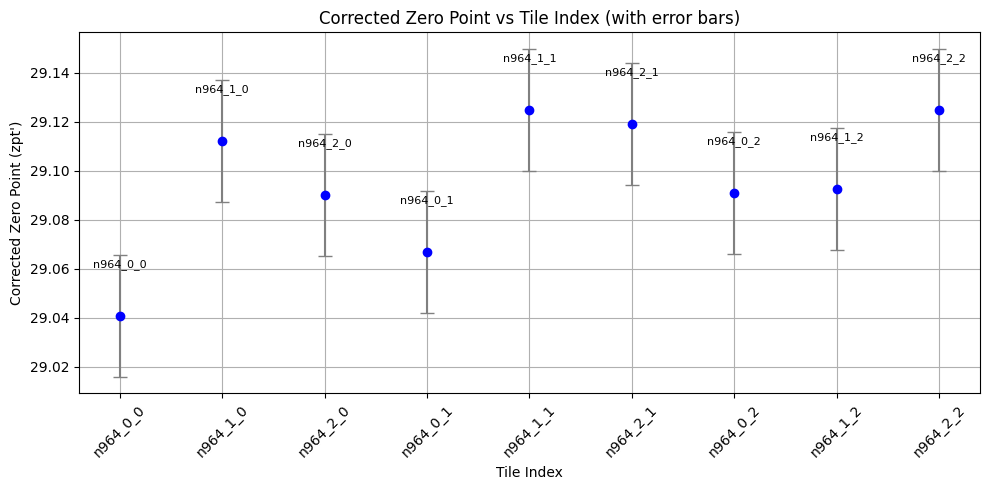

In [55]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# -----------------------
# Constants
# -----------------------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47  # arcsec
NARROW_BAND_APERTURES = 0.94  # arcsec
MIN_ERR = 0.01
SIGMA_CLIP = 3.0
PANSTARRS_CSV = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'

# -----------------------
# Functions
# -----------------------

def gaussian(x, mean, fwhm):
    sigma = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x - mean, 2.) / (2 * sigma**2))

def calculate_k_constant(aperture_radius, seeing):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))[0]
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))[0]
    return infinite_integral / definite_integral

def calculate_k_constant_mag(aperture_radius, seeing):
    k = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k)

def straight_line(x, alpha, zpt):
    return alpha * x + zpt

def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        popt, _ = curve_fit(straight_line, x[mask], y[mask], sigma=yerr[mask], absolute_sigma=True)
        residuals = y - straight_line(x, *popt)
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std
    return x[mask], y[mask], yerr[mask], popt

def bottom_limit(x):
    return 1 * x + 28.8

def upper_limit(x):
    return 1 * x + 29.1

def read_sextractor_catalog(filepath):
    try:
        data = np.genfromtxt(filepath, comments='#')
        return data
    except Exception as e:
        raise RuntimeError(f"Error reading catalog {filepath}: {e}")

# -----------------------
# Load Pan-STARRS Data
# -----------------------
pan = pd.read_csv(PANSTARRS_CSV)
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()

# -----------------------
# Catalog List
# -----------------------
decam_files = [
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_0_0.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_0_1.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_0_2.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_1_0.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_1_1.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_1_2.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_2_0.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_2_1.cat',
    '/Users/aishwarya/Documents/Lyman_alpha/N964/N964_cut/n964_2_2.cat'
]

# -----------------------
# Process and Store Results
# -----------------------

ra_list = []
dec_list = []
zpt_corr_list = []
tile_names = []

for filepath in decam_files:
    print(f"\nProcessing: {os.path.basename(filepath)}")
    try:
        data = read_sextractor_catalog(filepath)
        if data.ndim != 2 or data.shape[1] < 10:
            raise ValueError("Invalid catalog format: expecting at least 10 columns")

        ra_center = np.mean(data[:, 8])  # ALPHAPEAK_J2000
        dec_center = np.mean(data[:, 9])  # DELTAPEAK_J2000
        mag_auto = data[:, 4] + MAG_ZEROPOINT
        magerr_auto = data[:, 5]

        # Truncate to match Pan-STARRS size
        n = min(len(z), len(mag_auto))
        z_cut = z[:n]
        y_cut = y[:n]
        z_err_cut = z_err[:n]
        y_err_cut = y_err[:n]
        mag_auto = mag_auto[:n]
        magerr_auto = magerr_auto[:n]

        valid_idx = y_cut != -999
        z_cut = z_cut[valid_idx]
        y_cut = y_cut[valid_idx]
        z_err_cut = z_err_cut[valid_idx]
        y_err_cut = y_err_cut[valid_idx]
        mag_auto = mag_auto[valid_idx]
        magerr_auto = magerr_auto[valid_idx]

        delta_pan = z_cut - y_cut
        delta_decam = z_cut - mag_auto
        delta_pan_err = np.hypot(z_err_cut, y_err_cut)
        delta_decam_err = np.hypot(z_err_cut, magerr_auto)
        delta_decam_err = np.clip(delta_decam_err, MIN_ERR, None)

        cut_x = (delta_pan > -0.2) & (delta_pan < 0.6)
        cut_y = (delta_decam > 28.75) & (delta_decam < 29.752)
        valid = cut_x & cut_y

        delta_pan = delta_pan[valid]
        delta_decam = delta_decam[valid]
        delta_pan_err = delta_pan_err[valid]
        delta_decam_err = delta_decam_err[valid]

        valid_range = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
        delta_pan = delta_pan[valid_range]
        delta_decam = delta_decam[valid_range]
        delta_pan_err = delta_pan_err[valid_range]
        delta_decam_err = delta_decam_err[valid_range]

        delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, _ = sigma_clip_fit(
            delta_pan, delta_decam, delta_decam_err, sigma=SIGMA_CLIP
        )

        popt, pcov = curve_fit(
            straight_line,
            delta_pan_clipped,
            delta_decam_clipped,
            sigma=delta_decam_err_clipped,
            absolute_sigma=True
        )
        perr = np.sqrt(np.diag(pcov))

        k_correction = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
        zpt_prime = popt[1] - k_correction

        print(f"Slope (alpha):         {popt[0]:.4f} ± {perr[0]:.4f}")
        print(f"Intercept (zpt):       {popt[1]:.4f} ± {perr[1]:.4f}")
        print(f"K-correction (mag):    {k_correction:.4f}")
        print(f"Corrected ZPT (zpt'):   {zpt_prime:.4f}")

        ra_list.append(ra_center)
        dec_list.append(dec_center)
        zpt_corr_list.append(zpt_prime)
        tile_names.append(os.path.basename(filepath).replace('.cat', ''))

    except Exception as e:
        print(f"Failed to process {filepath}: {e}")

# -----------------------
# Plot: Index vs Corrected ZPT'
# -----------------------

# -----------------------
# Plot: Index vs Corrected ZPT' (with error bars)
# -----------------------

# Desired tile order for indexing
tile_order = ['n964_0_0', 'n964_1_0', 'n964_2_0',
              'n964_0_1', 'n964_1_1', 'n964_2_1',
              'n964_0_2', 'n964_1_2', 'n964_2_2']

tile_index_map = {name: idx for idx, name in enumerate(tile_order)}
indices = [tile_index_map.get(tile, -1) for tile in tile_names]

# Filter out unmatched tiles
valid_plot_idx = [i for i in range(len(indices)) if indices[i] != -1]
x_indices = [indices[i] for i in valid_plot_idx]
y_zpts = [zpt_corr_list[i] for i in valid_plot_idx]
labels = [tile_names[i] for i in valid_plot_idx]
zpt_errors = [perr[1] for i in valid_plot_idx]  # Add this list if not already created

plt.figure(figsize=(10, 5))

# Use error bars
plt.errorbar(x_indices, y_zpts, yerr=zpt_errors, fmt='o', color='blue',
             ecolor='gray', elinewidth=1.5, capsize=5, label='Tiles')

# Add tile name annotations
for i, label in enumerate(labels):
    plt.text(x_indices[i], y_zpts[i] + 0.02, label, ha='center', fontsize=8)

plt.xticks(ticks=range(len(tile_order)), labels=tile_order, rotation=45)
plt.ylabel("Corrected Zero Point (zpt')")
plt.xlabel("Tile Index")
plt.title("Corrected Zero Point vs Tile Index (with error bars)")
plt.grid(True)
plt.tight_layout()
plt.show()



In [56]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# Input RA and Dec in degrees
ra_list = [357.072185, 358.009069]
dec_list = [-31.518380, -31.266526]

# Create ICRS coordinates
coords = SkyCoord(ra=ra_list*u.degree, dec=dec_list*u.degree, frame='icrs')

# Print in sexagesimal format
for i, c in enumerate(coords):
    print(f"Source {i+1}:")
    print(f"  RA  (deg): {c.ra.degree:.6f}")
    print(f"  Dec (deg): {c.dec.degree:.6f}")
    print(f"  RA  (hms): {c.ra.to_string(unit=u.hour, sep=':', precision=2)}")
    print(f"  Dec (dms): {c.dec.to_string(unit=u.degree, sep=':', precision=2)}")
    print()


Source 1:
  RA  (deg): 357.072185
  Dec (deg): -31.518380
  RA  (hms): 23:48:17.32
  Dec (dms): -31:31:06.17

Source 2:
  RA  (deg): 358.009069
  Dec (deg): -31.266526
  RA  (hms): 23:52:02.18
  Dec (dms): -31:15:59.49

